# Drug Sentiment Analysis — end-to-end

**Task.** Each row is a patient comment plus the name of one drug. Predict the sentiment *toward that drug*:
`0` positive, `1` negative, `2` neutral. **Metric:** weighted F1.

**Why it is not plain sentiment analysis.** One comment can mention several drugs and praise one while blaming
another, so the label belongs to the (comment, drug) pair, not to the text. Everything in this project follows from
that: the model reads a window of sentences around the drug it is asked about, with the drug names masked.

**How to read this notebook.** It is the story of the finished project and runs top to bottom in a couple of
minutes, because it loads the artifacts the pipeline wrote rather than recomputing them. The heavy stages are in
the package and are run from the command line:

```bash
uv run python main.py all      # ingest -> preprocess -> embed -> train -> evaluate -> predict
uv run pytest                  # the test suite
```

| Section | Brief's step |
|---|---|
| 1. The data | Understanding the data |
| 2. What the data said | Exploratory analysis |
| 3. Making each row about its drug | Preprocessing / feature engineering |
| 4. Features | Feature engineering |
| 5. Validation | Model building |
| 6. Choosing a model | Model selection |
| 7. Results | Evaluation |
| 8. Where it fails, and what each decision was worth | Evaluation |
| 9. Scoring a new comment | Inference |
| 10. Submission and reproducibility | Submission |

In [1]:
import json
import warnings

import pandas as pd
from IPython.display import Image, Markdown, display

from drug_sentiment.config import get_config

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 90)

cfg = get_config()
REPORTS, FIGURES = cfg.artifacts.reports_dir, cfg.artifacts.figures_dir


def figure(name, width=920):
    display(Image(filename=str(FIGURES / f"{name}.png"), width=width))


def table(name, **kwargs):
    return pd.read_csv(REPORTS / f"{name}.csv", **kwargs)


print("project root:", cfg.data.train_path.parents[2])

project root: E:\AV_Capstone_Project


## 1. The data

`train.csv` has a comment, the drug it is about and the label; `test.csv` has everything but the label.

In [2]:
from drug_sentiment.data.ingestion import count_physical_lines, load_raw_data

raw = load_raw_data(cfg)
display(raw.train.head(3))

print(f"train: {len(raw.train):,} records   test: {len(raw.test):,} records")
print(f"physical lines in the files: {count_physical_lines(cfg.data.train_path):,} and "
      f"{count_physical_lines(cfg.data.test_path):,}")
print(f"sample_submission ids: {len(raw.sample_submission):,}")

[2026-09-15 10:24:00,815] INFO drug_sentiment.data.ingestion:77 - train: 5279 records from 5619 physical lines (multi-line comments)


[2026-09-15 10:24:00,854] INFO drug_sentiment.data.ingestion:77 - test: 2924 records from 3107 physical lines (multi-line comments)


[2026-09-15 10:24:00,867] INFO drug_sentiment.data.ingestion:83 - Raw data validation passed


,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,"Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t...",gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,"I can completely understand why you’d want to try it. But, results reported in lecture...",gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 receptors rather than 1-5 like Fingolimod. Ho...,fingolimod,2


train: 5,279 records   test: 2,924 records
physical lines in the files: 5,619 and 3,107
sample_submission ids: 2,924


**Finding — the row counts in the brief are line counts.** The brief quotes 5,619 / 3,107 rows; the files hold
**5,279** and **2,924** records. Comments contain line breaks inside quoted CSV fields, so a text editor counts more
lines than there are records. `sample_submission` has 2,924 ids, which settles it: the submission has 2,924 rows.

**Checks that passed:** no missing values, no duplicate ids, no case where the same (comment, drug) pair carries two
different labels.

In [3]:
counts = raw.train[cfg.data.target_col].value_counts().sort_index()
summary = pd.DataFrame({
    "label": [cfg.data.label_names[label] for label in counts.index],
    "rows": counts.to_numpy(),
    "share": (counts / counts.sum()).round(3).to_numpy(),
})
display(summary)

from sklearn.metrics import f1_score
majority = f1_score(raw.train[cfg.data.target_col], [2] * len(raw.train), average="weighted")
print(f"always answering neutral scores weighted F1 {majority:.3f} - the number any model has to beat")

,label,rows,share
0,positive,617,0.117
1,negative,837,0.159
2,neutral,3825,0.725


always answering neutral scores weighted F1 0.609 - the number any model has to beat


## 2. What the data said

The full exploration is in [`NoteBook/01_EDA.ipynb`](NoteBook/01_EDA.ipynb); these are the findings that changed the
design.

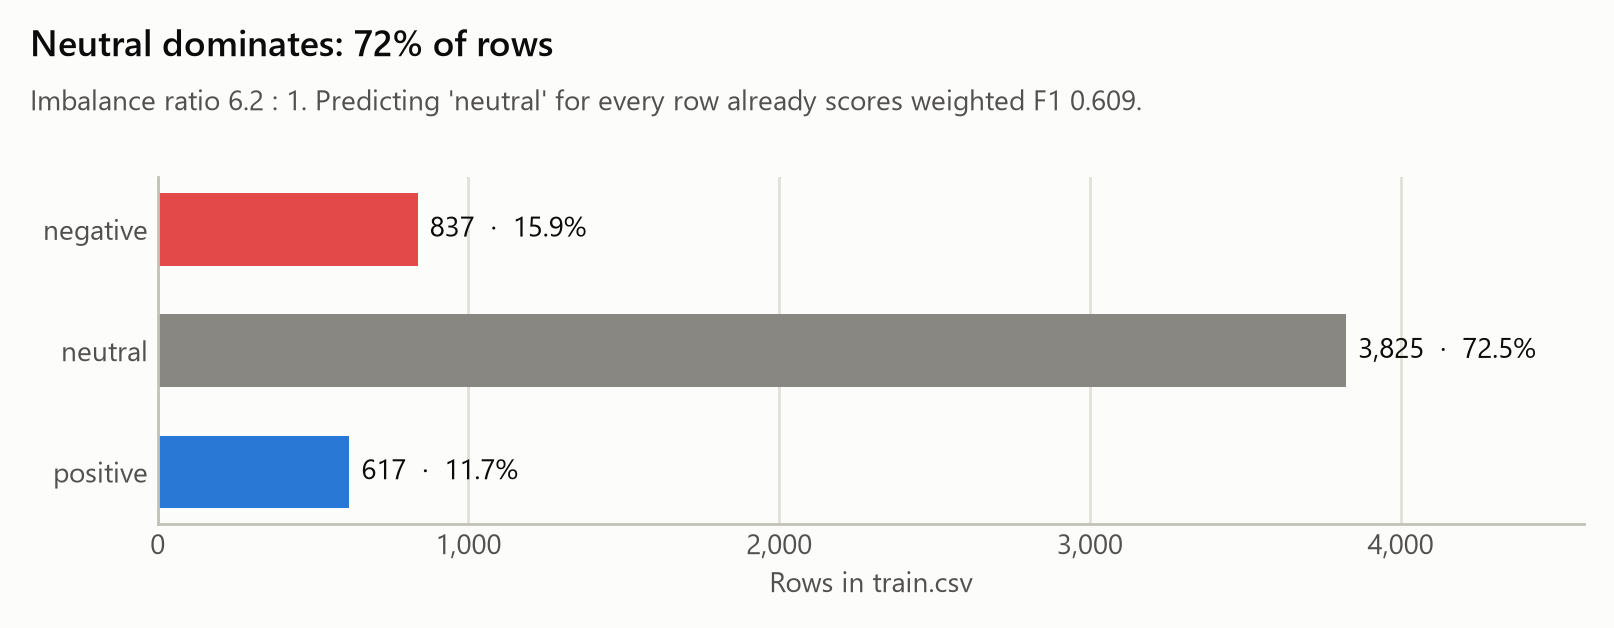

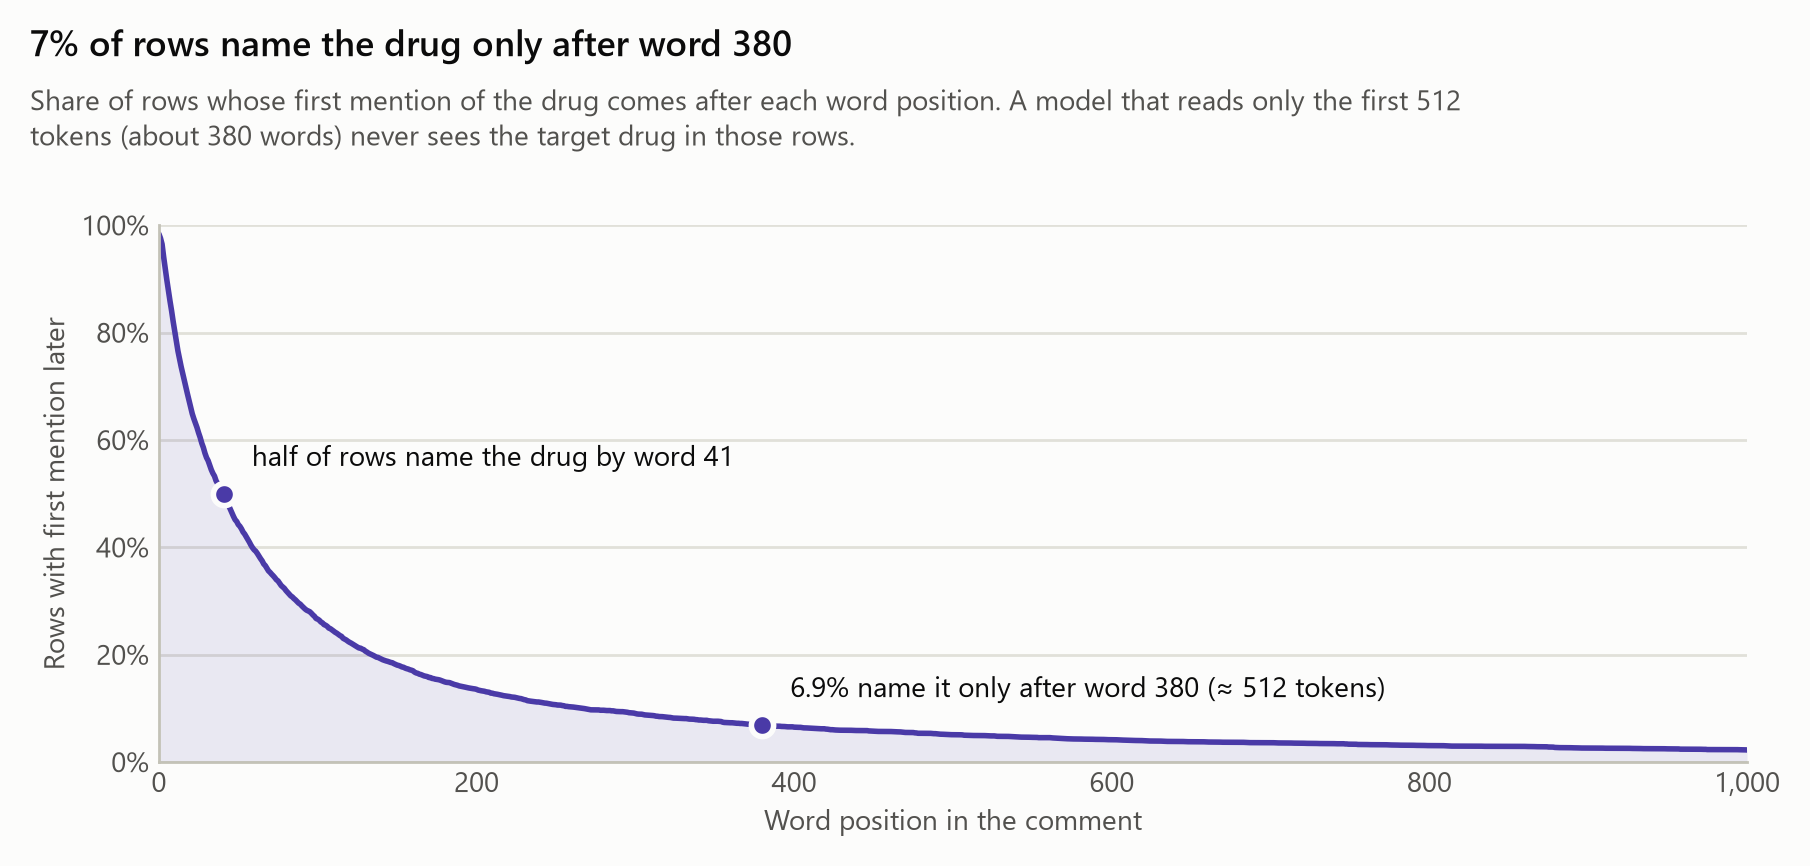

In [4]:
figure("eda_01_class_distribution")
figure("eda_05_first_mention_position")

| Finding | Decision it forced |
|---|---|
| 72.5% of rows are neutral | Weighted F1 as the metric, `class_weight="balanced"`, macro F1 watched alongside |
| Median comment 807 characters, longest 128k | Cap what the model reads; a long comment is mostly noise for one drug |
| In 6.9% of rows the drug first appears after word 380 | Never truncate from the start — centre the text on the drug |
| 88 comments appear with several drugs (186 rows) | Group the cross-validation folds by comment, or scores are inflated |
| 102 drugs in train, 9 test drugs unseen, several misspelt | A drug lexicon with synonyms and fuzzy matching |
| Drug sentiment is not uniform (mean label purity 0.835) | Keep the drug identity as a feature, but mask the name in the text |

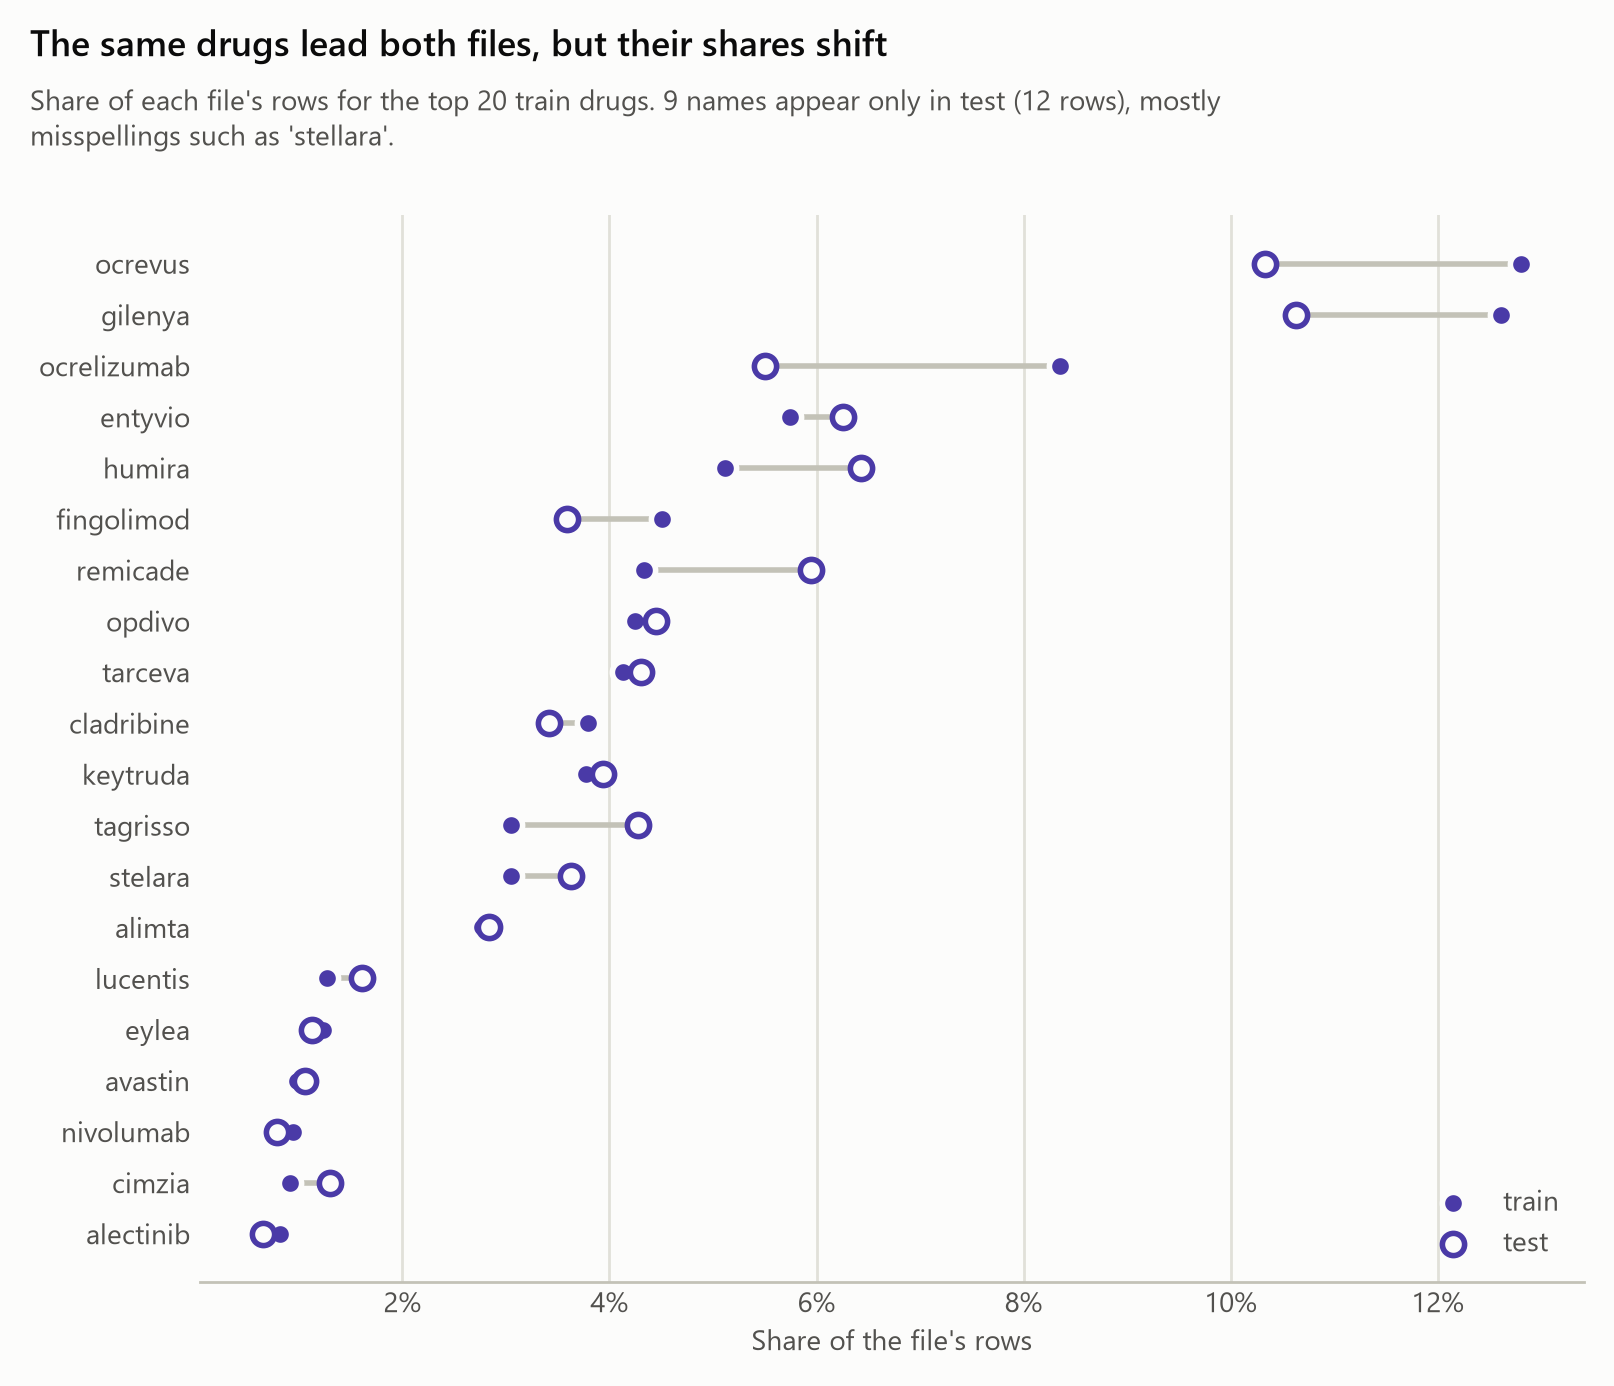

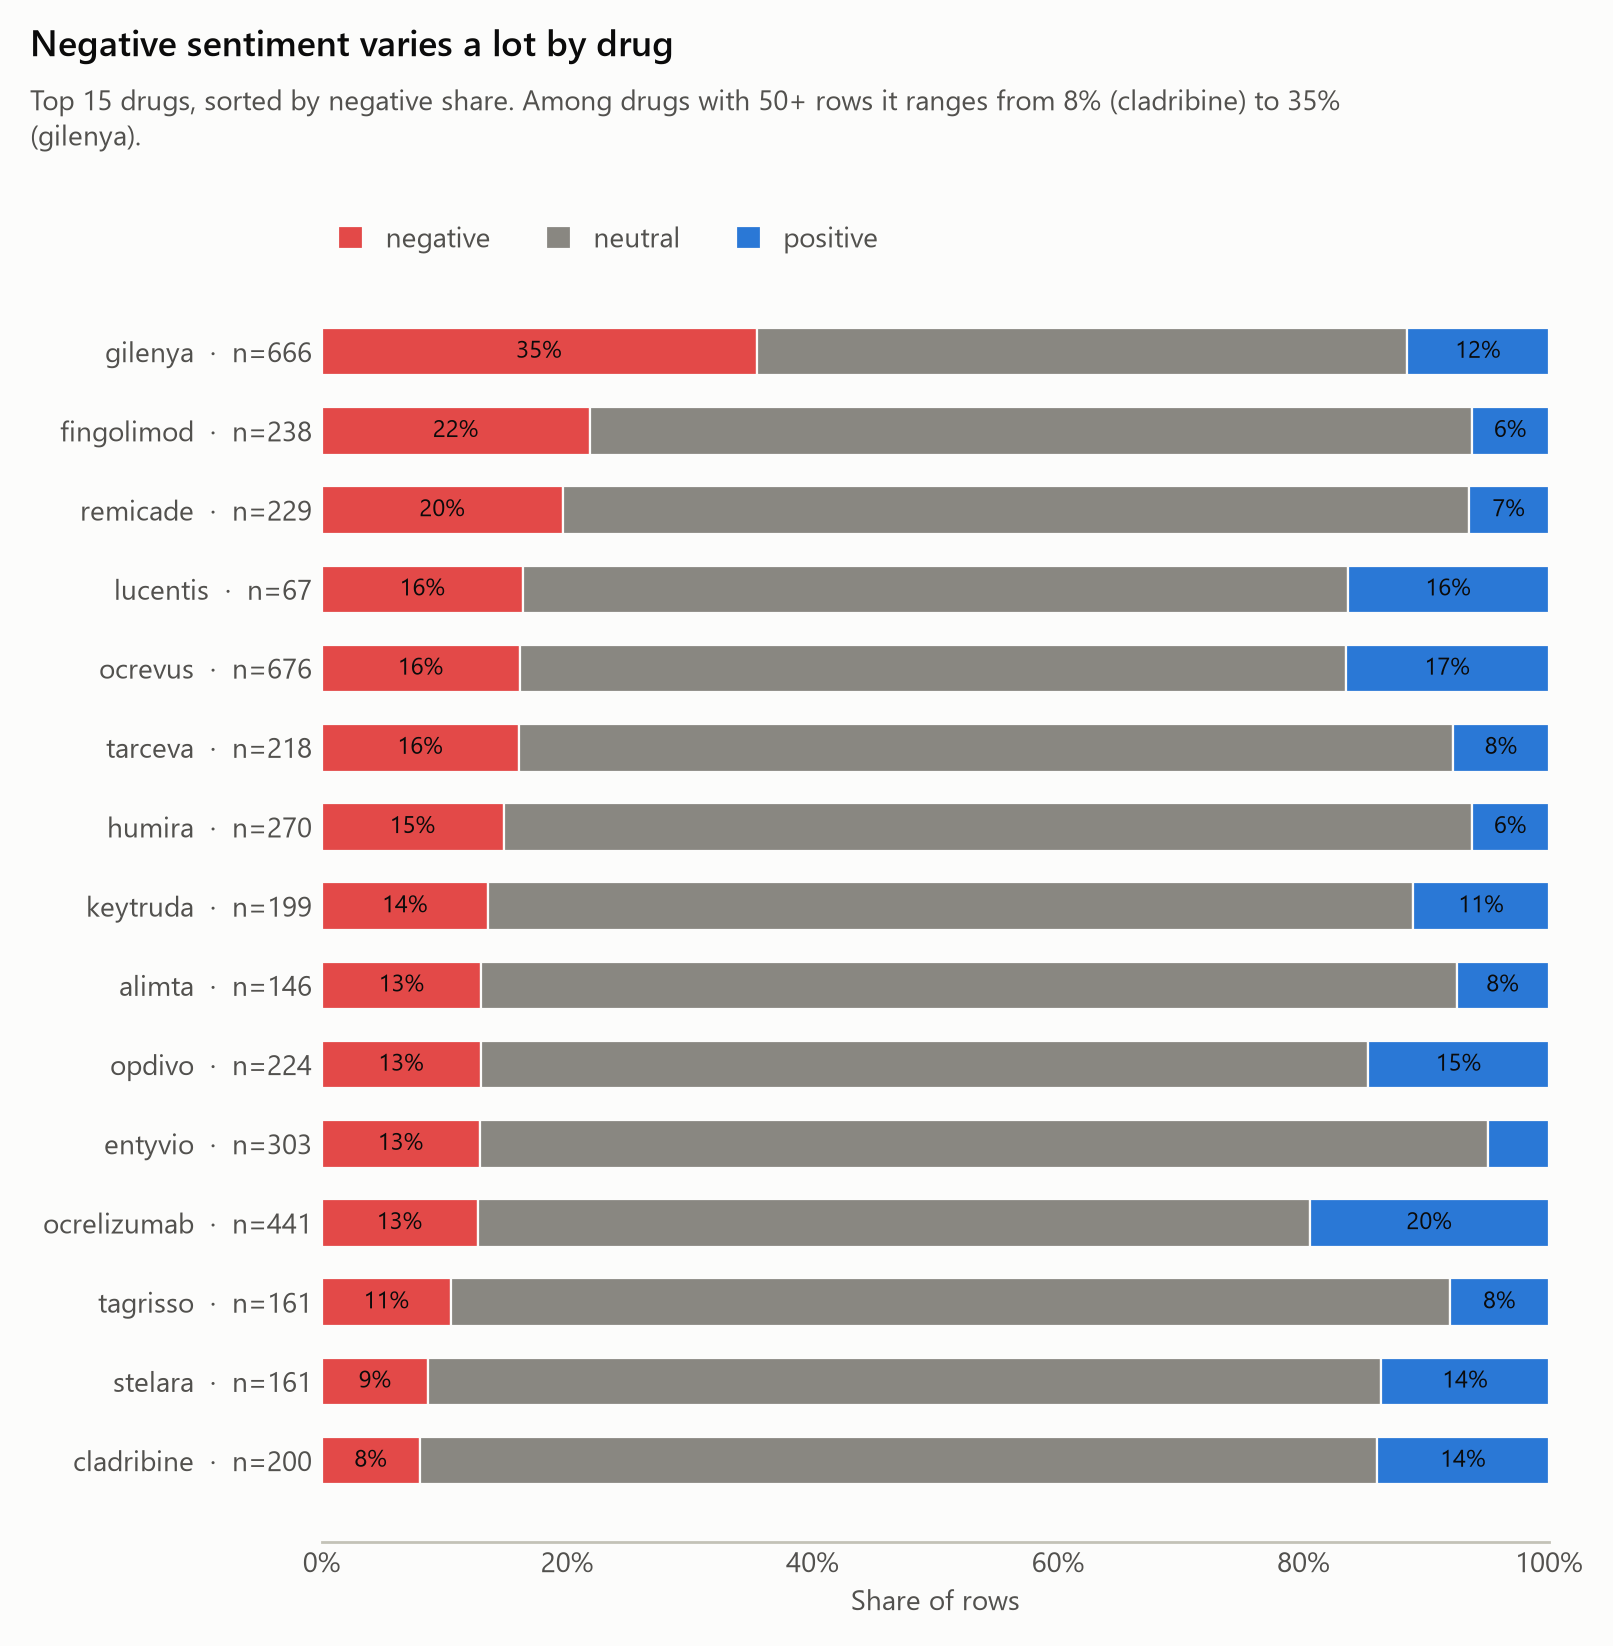

In [5]:
figure("eda_02_drug_frequency")
figure("eda_03_sentiment_by_drug")

## 3. Making each row about its drug

The preprocess stage turns one raw row into the columns the model needs. Everything is computed from that row alone
— no labels, no other rows — so the pickles it writes are safe to reuse for every model and every fold.

The window: find every mention of the target drug and keep those sentences, cap at 250 words, then mask — the target
drug becomes `targetdrug`, every other known drug becomes `otherdrug`. Wider windows (±1 and ±2 sentences) are stored
in the same file as `ctx_k1` and `ctx_k2`; section 8 shows the measurement that chose between them.

In [6]:
from drug_sentiment.utils.io import load_pickle

train = load_pickle(cfg.artifacts.train_preprocessed)
print(f"{train.shape[0]:,} rows x {train.shape[1]} columns")
print(list(train.columns))

5,279 rows x 29 columns
['unique_hash', 'drug', 'text', 'drug_norm', 'text_clean', 'full_masked', 'ctx_k0', 'ctx_k1', 'ctx_k2', 'ctx_natural', 'match_type', 'mention_count', 'first_mention_pos', 'n_mention_sentences', 'n_other_drugs', 'char_count', 'word_count', 'is_long_doc', 'window_word_count', 'exclamation_count', 'question_count', 'negation_count', 'first_person_count', 'vader_window_compound', 'vader_window_pos', 'vader_window_neg', 'vader_full_mean', 'sentiment', 'fold']


In [7]:
# One comment, two drugs: the same text, but each row sees its own window.
shared_text = train[train.duplicated("text", keep=False)].iloc[0]["text"]
for _, row in train[train["text"] == shared_text].iterrows():
    display(Markdown(f"**drug:** `{row['drug']}` — label **{cfg.data.label_names[row['sentiment']]}**, "
                     f"matched `{row['match_type']}`, mentioned {row['mention_count']}x"))
    print(row["ctx_k1"][:420], "\n")

**drug:** `remicade` — label **neutral**, matched `exact`, mentioned 1x

dx crohn s in june 2000 yay tried 5 asas azathioprine 6mp targetdrug methotrexate otherdrug diets 1st surgery 20 2 13 subtotal colectomy with end ileostomy 



**drug:** `humira` — label **neutral**, matched `exact`, mentioned 1x

dx crohn s in june 2000 yay tried 5 asas azathioprine 6mp otherdrug methotrexate targetdrug diets 1st surgery 20 2 13 subtotal colectomy with end ileostomy 



## 4. Features

Four blocks, all built from the drug window, assembled inside the model pipeline so every fitted step sees training
rows only.

| Block | What it is | Why |
|---|---|---|
| TF-IDF | word 1–2-grams + character 2–5-grams, stop words minus negations | the words that carry sentiment; character n-grams survive the misspellings patients write |
| Handcrafted | mention count and position, other drugs, lengths, `!`/`?`, negations, first-person words | how the comment talks about *this* drug |
| VADER | window compound/pos/neg, plus the mean sentence score of the whole comment | a sentiment prior that needs no training |
| MiniLM | 384-d frozen sentence embedding of the unmasked window | meaning TF-IDF cannot match ("didn't help" vs "was useless") |

In [8]:
from drug_sentiment.models.features import COUNT_FEATURES, SCALED_FEATURES, load_model_frame

frame = load_model_frame("train", cfg)
print(f"model frame: {frame.shape[0]:,} rows x {frame.shape[1]} columns "
      f"({len([c for c in frame.columns if c.startswith('minilm_')])} of them MiniLM)")
display(frame[COUNT_FEATURES + SCALED_FEATURES].describe().T.round(2))

model frame: 5,279 rows x 413 columns (384 of them MiniLM)


,count,mean,std,min,25%,50%,75%,max
mention_count,5279.0,2.20,4.47,0.00,1.00,1.00,2.00,140.00
n_mention_sentences,5279.0,1.95,3.59,0.00,1.00,1.00,2.00,102.00
n_other_drugs,5279.0,0.85,1.40,0.00,0.00,0.00,1.00,17.00
char_count,5279.0,2065.31,5055.19,5.00,414.00,803.00,1696.00,127666.00
word_count,5279.0,342.15,795.84,1.00,73.00,141.00,293.00,19611.00
window_word_count,5279.0,73.83,57.29,1.00,35.00,56.00,91.00,258.00
exclamation_count,5279.0,0.18,0.62,0.00,0.00,0.00,0.00,11.00
question_count,5279.0,0.26,0.65,0.00,0.00,0.00,0.00,8.00
negation_count,5279.0,0.90,1.20,0.00,0.00,1.00,1.00,14.00
first_person_count,5279.0,2.44,3.38,0.00,0.00,1.00,4.00,28.00


## 5. Validation

One split, made once in the preprocess stage and stored as a `fold` column, is reused by every model in this
project — otherwise a comparison measures the split as much as the model.

- **Stratified** by label, so each fold keeps the 72/16/12 class mix.
- **Grouped by comment text**, so a comment that appears with several drugs never sits in training and validation at
  the same time.
- **Fitted inside the fold**: TF-IDF vocabulary, SVD, scalers and the drug encoder are fitted on the training part
  only, then applied to the validation part.
- `test.csv` is read once, by the predict stage.

In [9]:
fold_mix = pd.crosstab(train["fold"], train["sentiment"].map(cfg.data.label_names), normalize="index").round(3)
display(fold_mix)
print("rows per fold:", train["fold"].value_counts().sort_index().to_dict())

sentiment,negative,neutral,positive
fold,,,
0,0.159,0.724,0.116
1,0.158,0.724,0.117
2,0.158,0.725,0.117
3,0.158,0.724,0.117
4,0.159,0.724,0.116


rows per fold: {0: 1056, 1: 1056, 2: 1055, 3: 1056, 4: 1056}


## 6. Choosing a model

[`NoteBook/model_expriments.ipynb`](NoteBook/model_expriments.ipynb) screened 10 classical models with base settings
on **half** the training data, tuned the **top 3** with Optuna on the **full** data, and picked the winner. Same
folds throughout.

,representation,valid_f1_weighted,valid_f1_macro,seconds
LinearSVC,sparse,0.7214,0.5543,18.9917
XGBoost,dense,0.7093,0.4903,91.6397
LogisticRegression,sparse,0.7024,0.5544,21.7177
GradientBoosting,dense,0.7018,0.5333,30.3858
SVC,dense,0.7002,0.5453,47.1363
LightGBM,dense,0.7002,0.4710,129.3659
ComplementNB,counts,0.6792,0.4323,0.3814
KNN,dense,0.6592,0.3800,2.0249
RandomForest,dense,0.6425,0.3465,23.5897
DecisionTree,dense,0.5736,0.4193,6.0300


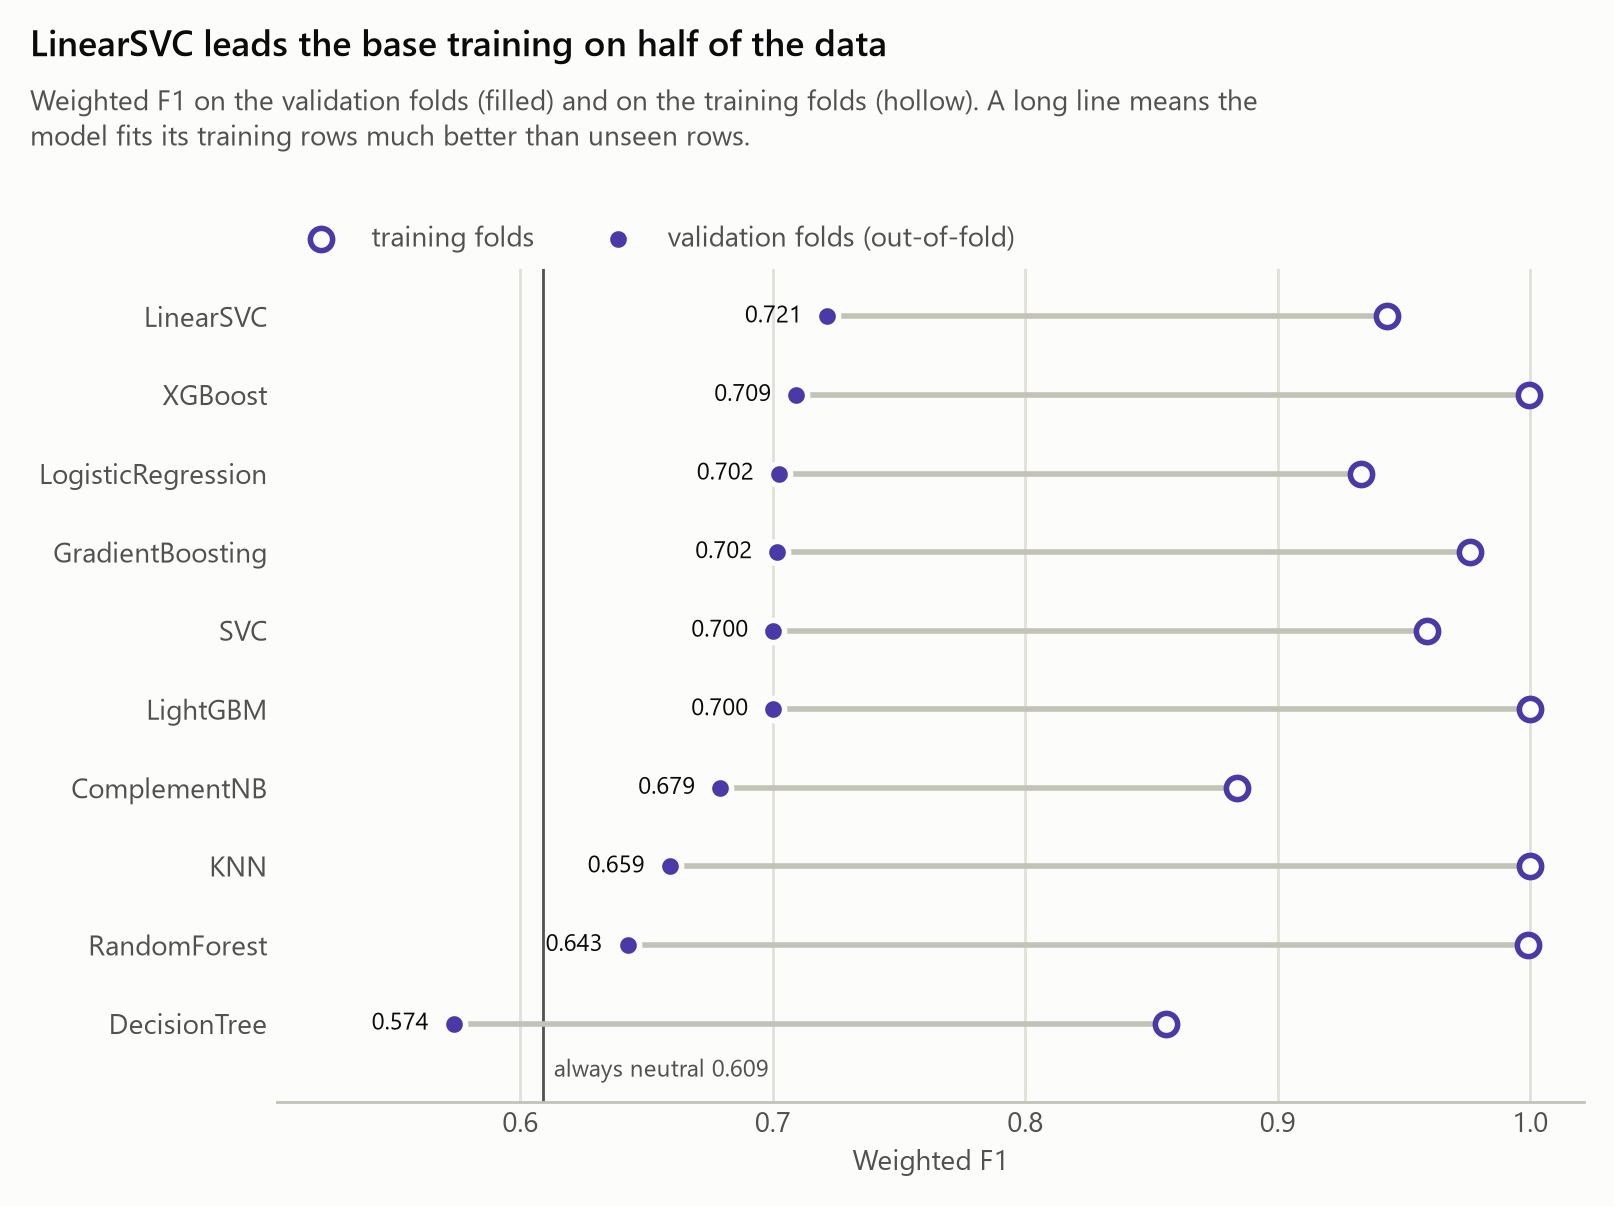

In [10]:
screening = table("model_screening_half", index_col=0)
display(screening[["representation", "valid_f1_weighted", "valid_f1_macro", "seconds"]].round(4))
figure("model_screening_half")

In [11]:
tuned = table("tuned_top3", index_col=0)
display(tuned[["base_valid_f1_weighted", "valid_f1_weighted", "valid_f1_macro", "fold_f1_std", "seconds"]].round(4))

display(table("window_c_search", index_col=None).head(6).round(4))

card = json.loads((cfg.artifacts.model_dir / "model_card.json").read_text())
display(Markdown(
    f"**Main model: `{card['model']}`** — {card['params']}, {card['n_features']:,} features, fitted on all "
    f"{card['trained_rows']:,} training rows in {card['fit_seconds']}s."
))

,base_valid_f1_weighted,valid_f1_weighted,valid_f1_macro,fold_f1_std,seconds
LinearSVC,0.7251,0.7274,0.5717,0.0043,43.4484
XGBoost,0.7077,0.7148,0.5242,0.0094,286.1441
LogisticRegression,0.6965,0.7093,0.5527,0.0057,73.4797


,text_column,C,f1_weighted,f1_macro,fold_f1_std,seconds
0,ctx_k0,0.0500,0.7353,0.5863,0.0038,44.1559
1,ctx_k0,0.0847,0.7338,0.5822,0.0055,53.7217
2,ctx_k2,0.0847,0.7294,0.5732,0.0092,81.4901
3,ctx_k0,0.1500,0.7288,0.5748,0.0079,72.0124
4,ctx_k0,0.0300,0.7283,0.5743,0.0056,36.6436
5,ctx_k1,0.0847,0.7274,0.5717,0.0043,69.5347


**Main model: `LinearSVC`** — {'C': 0.05, 'class_weight': 'balanced', 'max_iter': 20000}, 48,988 features, fitted on all 5,279 training rows in 16s.

**Why LinearSVC.** Best weighted F1 *and* best macro F1 of the tuned three, the steadiest across folds, seconds to
refit, and a linear model on TF-IDF keeps one weight per word — so every prediction can be traced back to the words
in the window, which matters in a medical setting and at the viva.

**One thing changed after this notebook.** The screening and tuning above used the ±1-sentence window. The
evaluation stage then measured the window itself and found the tighter one better, so `main.py window-search`
re-tuned `C` for each window — no window judged on another's regularisation — and the project switched to
`ctx_k0` with `C = 0.05`. The table below is that search.

The boosted trees (XGBoost, LightGBM) fit their training folds almost perfectly and gained little on unseen rows:
with 5k short texts, the sparse linear model is the better bias–variance trade.

## 7. Results

Out of fold on the training data — the same 5 folds, so these numbers are comparable with everything above.

,precision,recall,f1-score,support
positive,0.429,0.378,0.402,617.000
negative,0.528,0.515,0.521,837.000
neutral,0.826,0.846,0.836,3825.000
accuracy,0.739,0.739,0.739,0.739
macro avg,0.594,0.580,0.586,5279.000
weighted avg,0.732,0.739,0.735,5279.000


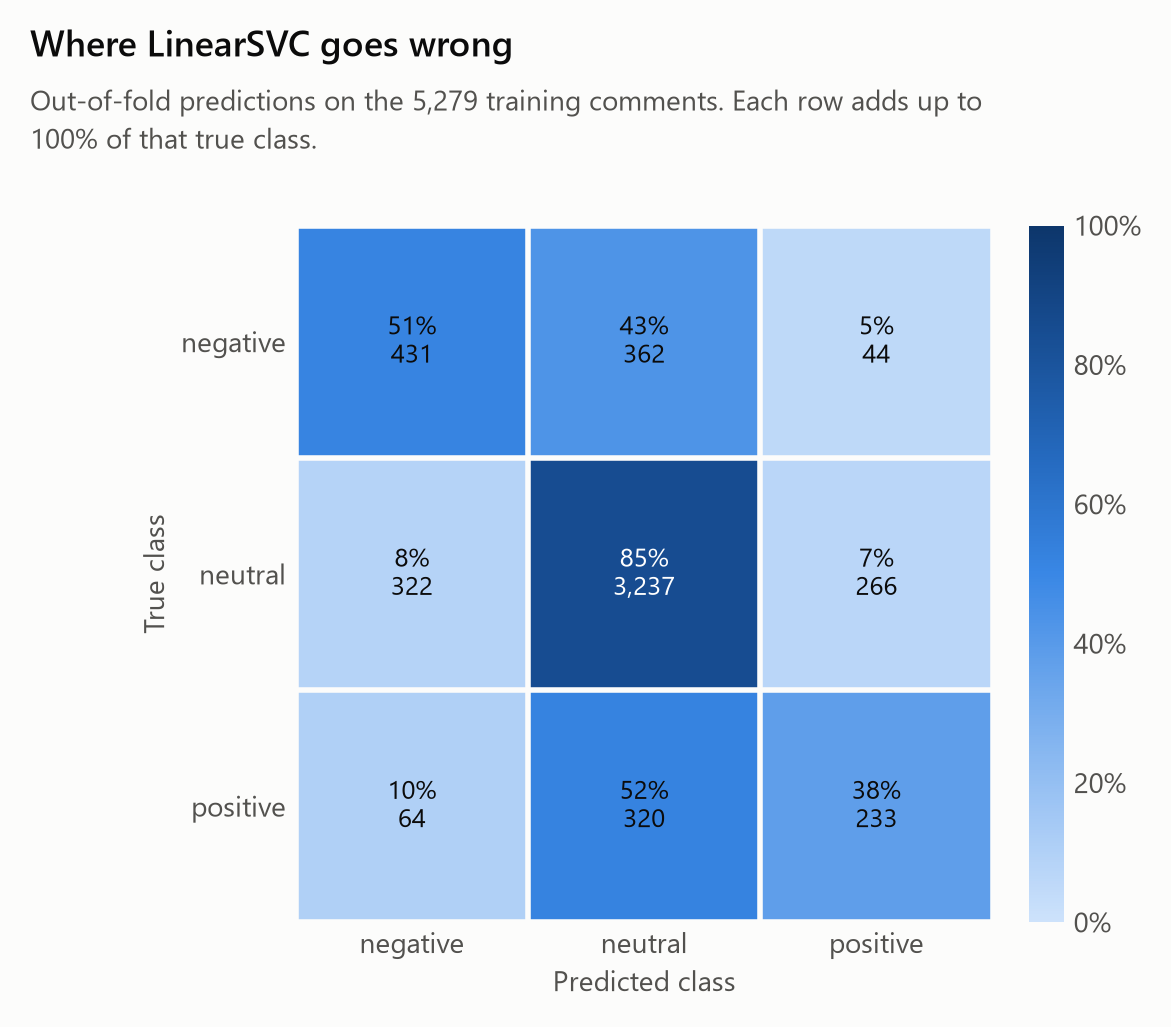

In [12]:
report = table("oof_classification_report", index_col=0)
display(report.round(3))
figure("eval_01_confusion_matrix", width=640)

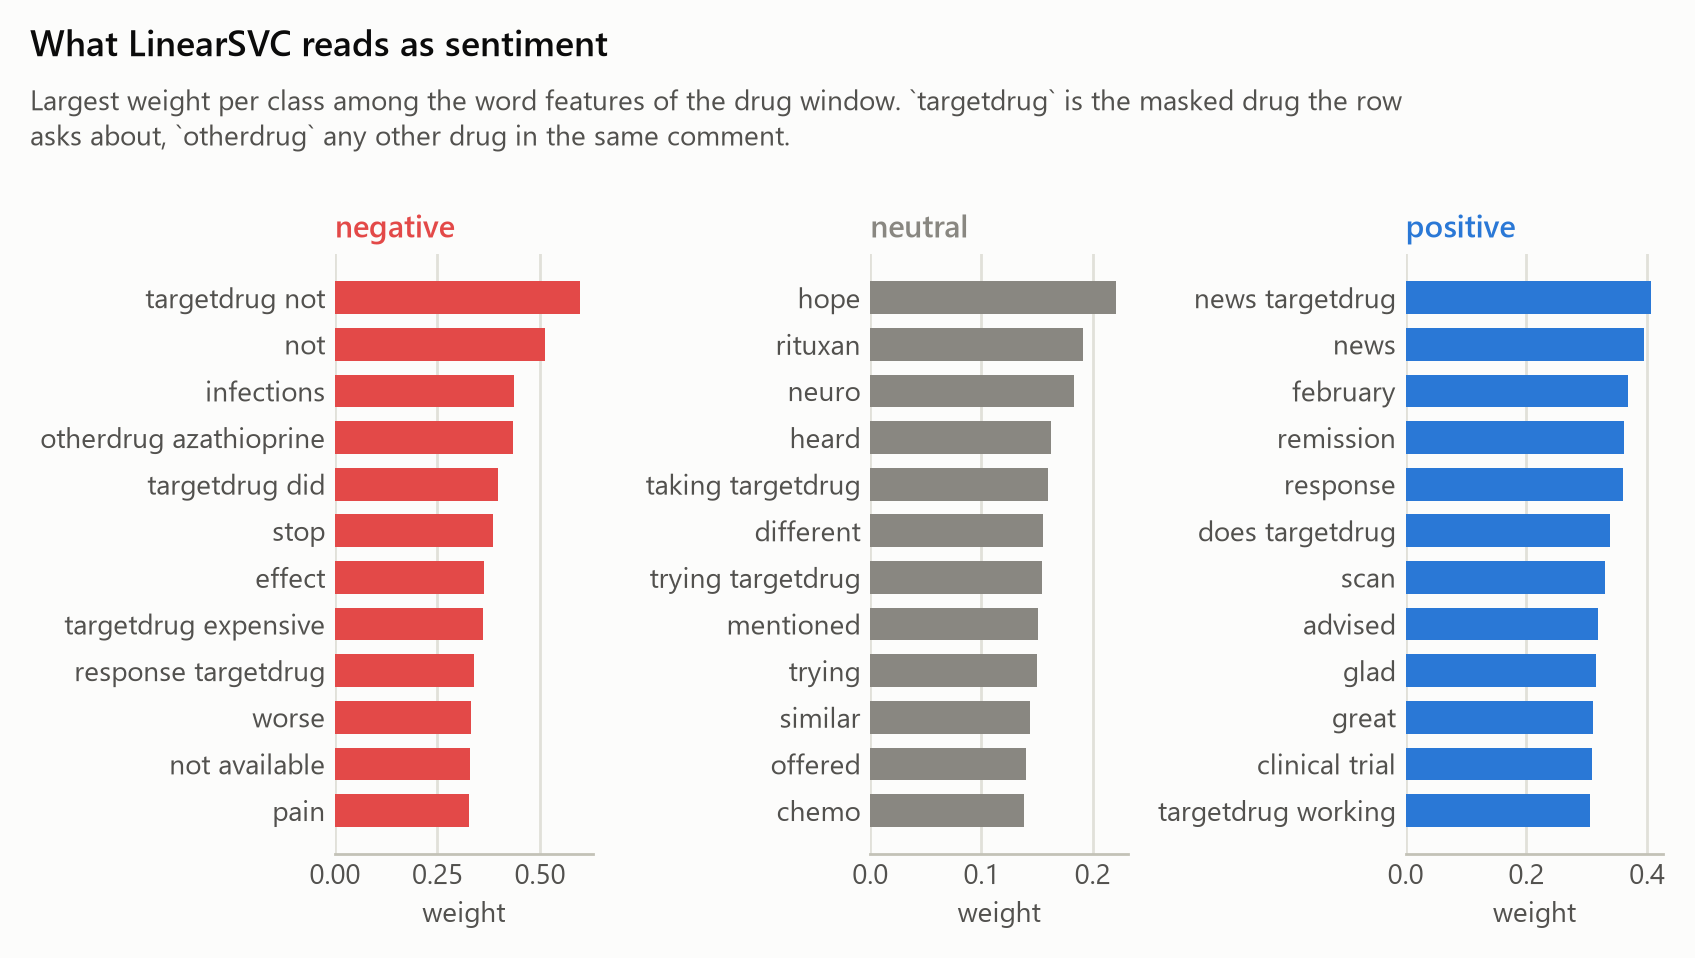

In [13]:
figure("eval_03_top_words")

## 8. Where it fails, and what each decision was worth

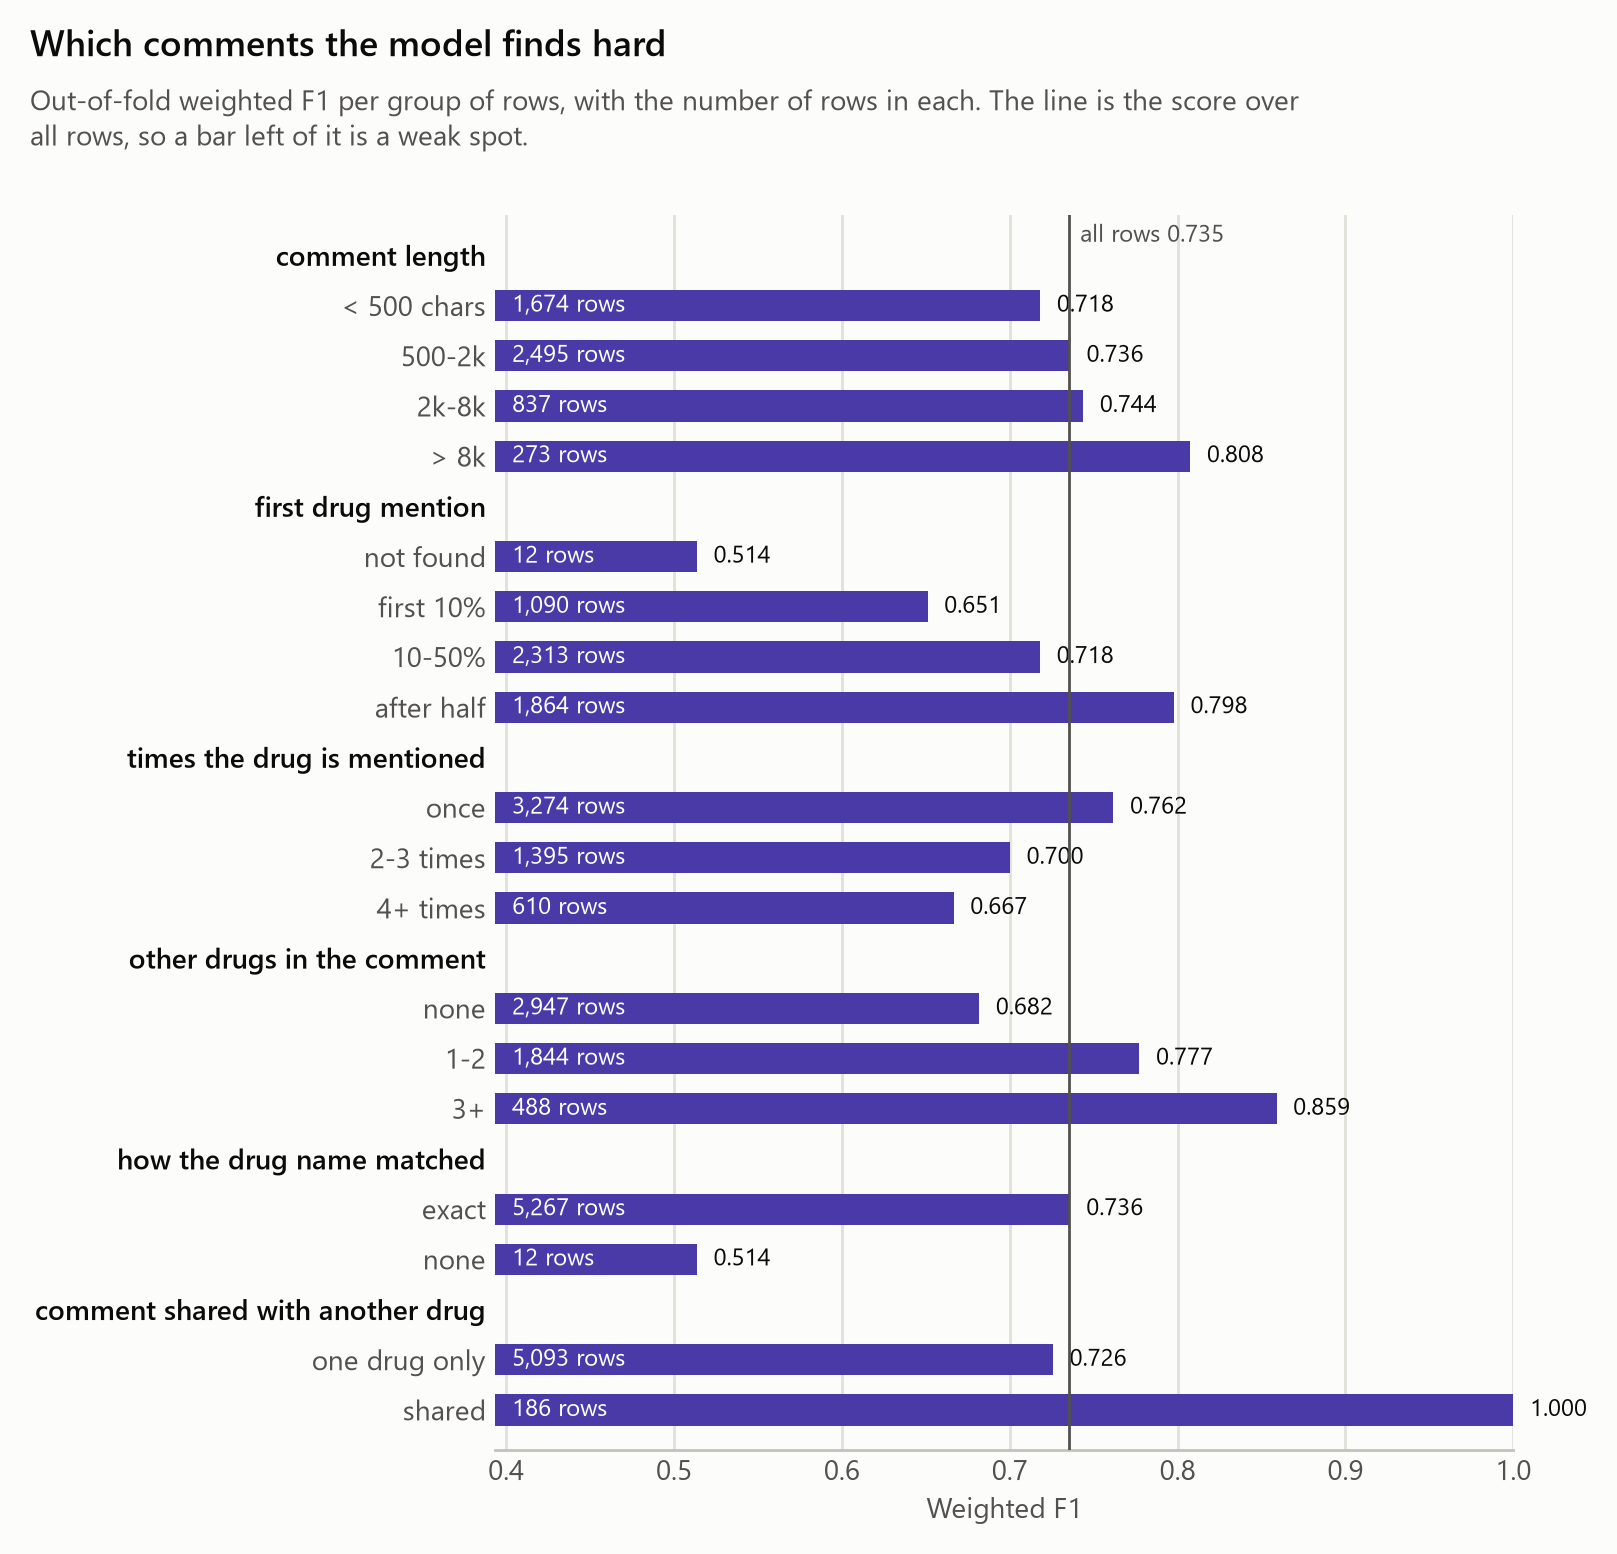

,dimension,slice,rows,share,f1_weighted,accuracy
4,first drug mention,not found,12,0.002,0.514,0.500
15,how the drug name matched,none,12,0.002,0.514,0.500
5,first drug mention,first 10%,1090,0.206,0.651,0.644
10,times the drug is mentioned,4+ times,610,0.116,0.667,0.661
11,other drugs in the comment,none,2947,0.558,0.682,0.679


In [14]:
figure("eval_02_slice_scores")
display(table("oof_slice_scores").nsmallest(5, "f1_weighted").round(3))

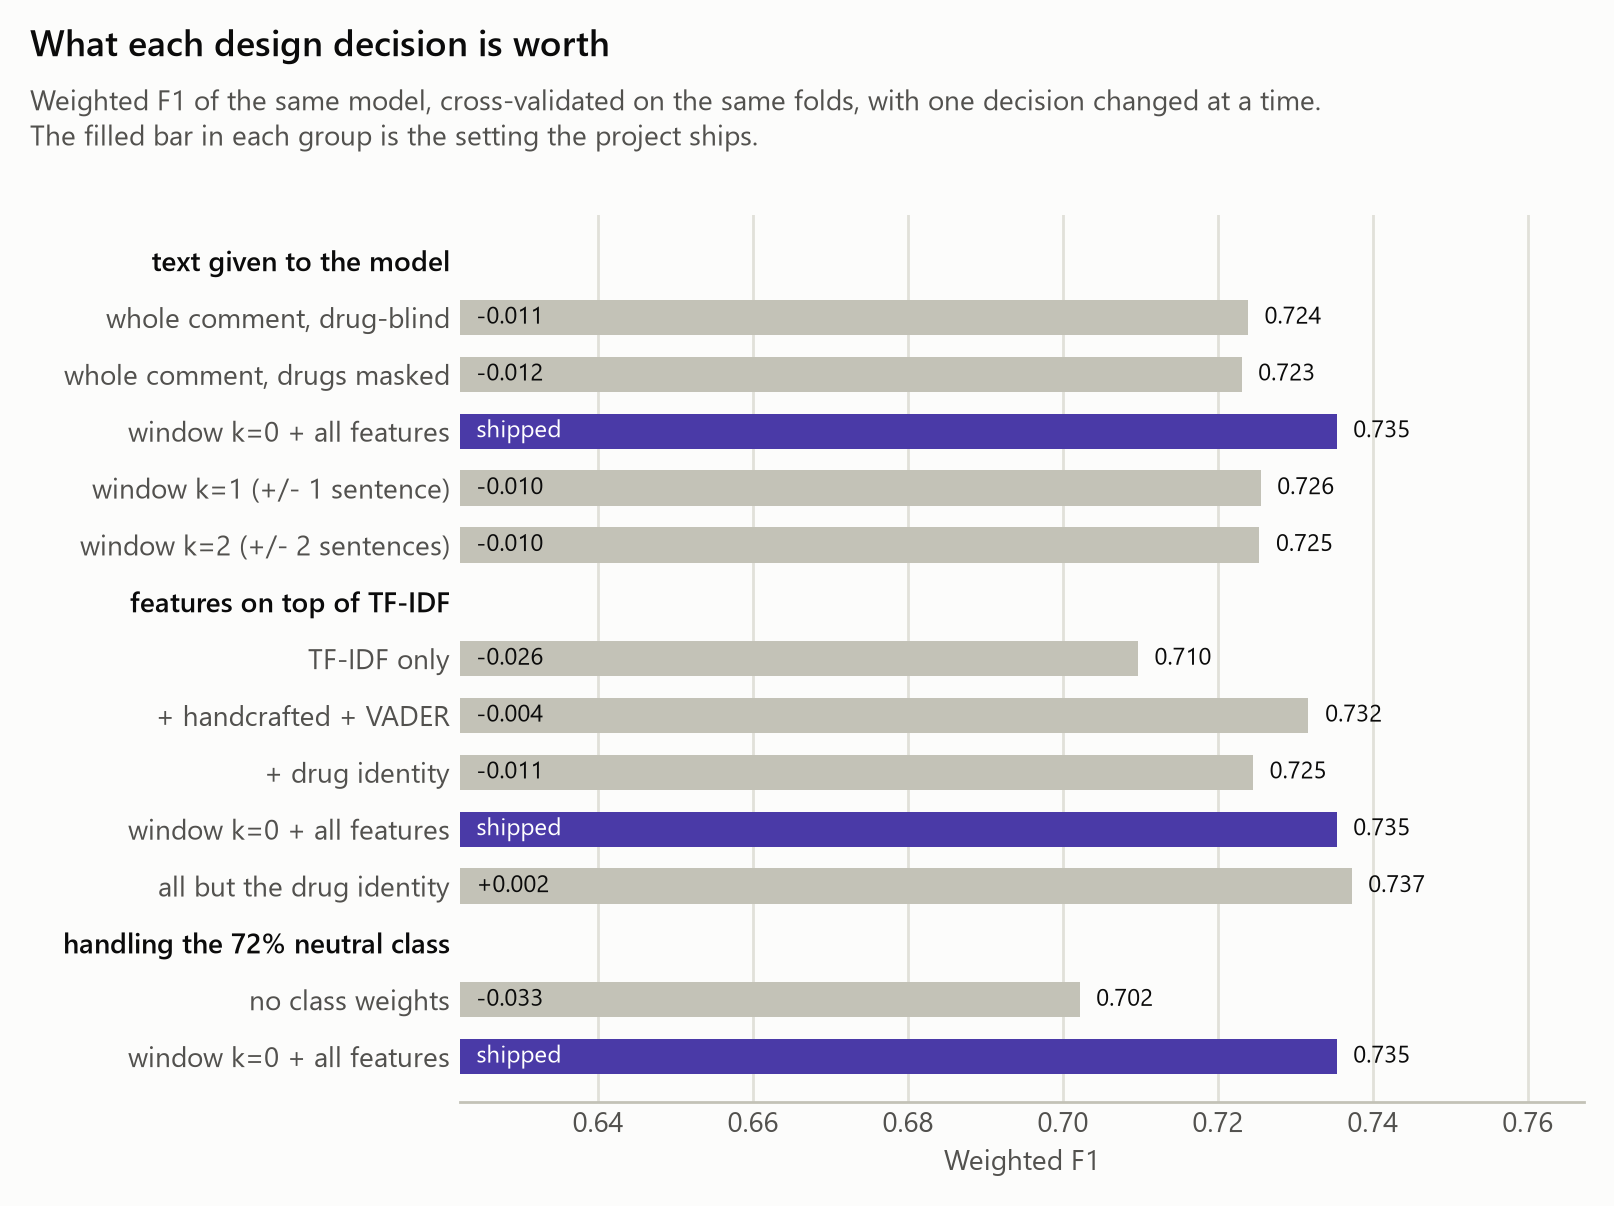

,group,variant,f1_weighted,f1_macro
0,text given to the model,"whole comment, drug-blind",0.7239,0.5666
1,text given to the model,"whole comment, drugs masked",0.7231,0.5642
2,text given to the model,window k=0 + all features,0.7353,0.5863
3,text given to the model,window k=1 (+/- 1 sentence),0.7255,0.5686
4,text given to the model,window k=2 (+/- 2 sentences),0.7253,0.5676
5,features on top of TF-IDF,TF-IDF only,0.7097,0.5212
6,features on top of TF-IDF,+ handcrafted + VADER,0.7317,0.5765
7,features on top of TF-IDF,+ drug identity,0.7245,0.5653
8,features on top of TF-IDF,window k=0 + all features,0.7353,0.5863
9,features on top of TF-IDF,all but the drug identity,0.7373,0.5884


In [15]:
figure("eval_04_ablations")
display(table("ablation_scores")[["group", "variant", "f1_weighted", "f1_macro"]].round(4))

In [16]:
display(table("oof_error_examples").head(8)[["drug", "true", "predicted", "window"]])

,drug,true,predicted,window
0,ocrevus,positive,neutral,i do not know much about the data for targetdrug but as it has an effect on progressiv...
1,remicade,negative,neutral,was on targetdrug now on otherdrug
2,alectinib,positive,neutral,again nsclc alk positive and began new targetdrug therapy this drug targetdrug much ea...
3,remicade,neutral,negative,about 3 weeks into starting the plaquenil and two weeks after my last targetdrug all o...
4,avastin,negative,neutral,my experiences have been abraxane targetdrug combo 6 months stopped bc it was kicking ...
5,ocrevus,neutral,negative,my neurologist insists that these problems are not from the targetdrug i call bs and i...
6,keytruda,positive,neutral,hi deb1313 i too have nsclc and was treated with targetdrug
7,ozurdex,neutral,negative,sorry should read targetdrug


## 9. Scoring a new comment

The same steps as training, applied to text that is not in either CSV: clean → find the drug → window and mask →
handcrafted and VADER → MiniLM → the fitted pipeline.

In [17]:
from drug_sentiment.inference.predict import DrugSentimentPredictor

predictor = DrugSentimentPredictor.from_artifacts(cfg)

comment = ("Keytruda is working really well for me, the tumour has shrunk twice now and I feel almost normal "
           "again. Opdivo was a disaster, it did nothing for a year and the fatigue was so bad I could not get out "
           "of bed.")

for drug in ("Keytruda", "Opdivo"):
    print(predictor.predict_one(drug, comment), chr(10))

E:\AV_Capstone_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1903.76it/s]

[2026-09-15 10:24:29,470] INFO drug_sentiment.models.train:83 - Main model LinearSVC from best_model_config.json: {'C': 0.05, 'class_weight': 'balanced', 'max_iter': 20000}


Keytruda: positive (0)
  scores      positive 0.47, negative 0.38, neutral 0.16
  drug match  exact, mentioned 1x
  window      targetdrug is working really well for me the tumour has shrunk twice now and i feel almost normal again 

Opdivo: negative (1)
  scores      positive 0.16, negative 0.68, neutral 0.17
  drug match  exact, mentioned 1x
  window      targetdrug was a disaster it did nothing for a year and the fatigue was so bad i could not get out of bed 



One comment, two drugs, opposite answers — the point of the whole design. Each row sees only the sentence about its
own drug, with the name masked to `targetdrug`.

Two honest caveats. The model is weakest exactly where this demo is strongest-looking: positive recall out of fold
is 38%, so short praise is often read as neutral. And when both drugs are discussed in *one* sentence, both rows get
the same window and the same answer — sentence-level labels would be the fix, and that is on the next-steps list.

## 10. Submission and reproducibility

In [18]:
from drug_sentiment.models.train import validate_submission

submission = pd.read_csv(cfg.artifacts.submission_file)
validate_submission(submission, pd.read_csv(cfg.data.sample_submission_path)["id"])
display(submission.head())

shares = submission["sentiment"].value_counts(normalize=True).sort_index()
print("checks passed:", len(submission), "rows, ids in test order, labels are integers 0/1/2")
print("predicted mix:", {cfg.data.label_names[label]: f"{share:.1%}" for label, share in shares.items()})

,id,sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,2
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,1
2,50b6d851bcff4f35afe354937949e9948975adf7,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,2


checks passed: 2924 rows, ids in test order, labels are integers 0/1/2
predicted mix: {'positive': '8.7%', 'negative': '15.1%', 'neutral': '76.2%'}


**Reproducing everything**

| Stage | Command | Output |
|---|---|---|
| Ingest | `uv run python main.py ingest` | record counts and validation checks |
| Preprocess | `uv run python main.py preprocess` | `artifacts/preprocessed/` pickles + drug lexicon |
| Embed | `uv run python main.py embed` | MiniLM embeddings |
| Train | `uv run python main.py train` | `artifacts/model/best_model.pkl` + model card |
| Evaluate | `uv run python main.py evaluate` | out-of-fold reports, error analysis, ablations |
| Predict | `uv run python main.py predict` | `artifacts/submission/predictions.csv` |
| Slides | `uv run python main.py slides` | `presentation/Drug_Sentiment_Capstone.pptx` |

Seed 42 everywhere, CPU only, no GPU. `uv run pytest` covers ingestion, cleaning, drug windows, the row-wise
guarantee of the preprocessing, embeddings, feature blocks, cross-validation and the submission validator.

**What I would do next:** fine-tune a domain transformer (BioBERT/PubMedBERT) on the masked windows on a GPU; treat
the neutral class explicitly (much of it is news and trial reports rather than opinion); fit a drug-level target
encoding inside the folds; blend the linear model with XGBoost, whose mistakes differ.